# Track some people

In [17]:
import torch
import torch.nn as nn
import os
from pathlib import Path

# ------------ Blocks --------------
class RC_Layer(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.sigma = nn.Parameter(torch.ones(1, channels, 1, 1))

    def fast_erf(self, x):
        return torch.tanh(1.702 * x)

    def forward(self, x):
        x_centered = (x - self.mu) / (self.sigma + 1e-5)
        phi = 0.5 * (1 + self.fast_erf(x_centered / 1.4142))
        weight = torch.where(x > self.mu, 1 - phi, phi)
        return x + x * weight

class SERegNetBottleneck(nn.Module):
    def __init__(self, in_c, out_c, stride=1, se_ratio=0.25, group_width=8, use_rc=True, is_last_block=False):
        super().__init__()
        self.use_rc = use_rc and is_last_block and out_c >= 256  

        mid_c = out_c
        groups = mid_c // group_width

        self.conv1 = nn.Conv2d(in_c, mid_c, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_c)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(mid_c, mid_c, kernel_size=3, stride=stride, padding=1,
                               groups=groups, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_c)
        self.relu2 = nn.ReLU(inplace=True)

        self.conv3 = nn.Conv2d(mid_c, out_c, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_c)

        se_c = max(1, int(out_c * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_c, se_c, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(se_c, out_c, kernel_size=1),
            nn.Hardsigmoid(inplace=True)
        )

        if self.use_rc:
            self.rc = RC_Layer(out_c)

        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )
        else:
            self.skip = nn.Identity()

        self.relu_out = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out * self.se(out)
        if self.use_rc:
            out = self.rc(out)
        return self.relu_out(out + self.skip(x))

# ------------ Unified Single-Head Model --------------
class BestenSingle(nn.Module): 
    def __init__(
        self,
        num_classes, 
        # Unified layer configuration: (repeats, output_channels, stride)
        layer_config = [(1, 64, 2), (1, 128, 2), (1, 256, 2), (1, 512, 2)],
        se_ratio=0.25, 
        group_width=8,                 
        use_rc=True
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
        )

        # Generate the unified sequential stages
        self.stages, final_out_c = self._make_stage(
            24, layer_config, se_ratio, group_width, use_rc)
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(final_out_c, num_classes)

    def _make_stage(self, in_c, config, se_ratio, group_width, use_rc):
        layers = []
        for repeat, out_c, stride in config:
            for i in range(repeat):
                block_stride = stride if i == 0 else 1
                is_last = (i == repeat - 1)
                layers.append(SERegNetBottleneck(
                    in_c if i == 0 else out_c,
                    out_c,
                    stride=block_stride,
                    se_ratio=se_ratio,
                    group_width=group_width,
                    use_rc=use_rc,
                    is_last_block=is_last
                ))
            in_c = out_c
        return nn.Sequential(*layers), in_c

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        out = self.fc(self.pool(x).flatten(1))
        return out

print("Architecture loaded successfully.")

Architecture loaded successfully.


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the core datasets
pa_train_df = pd.read_csv('./data/pa-100k/train.csv')
pa_val_df = pd.read_csv('./data/pa-100k/val.csv')
peta_full_df = pd.read_csv('./data/peta/peta.csv')

# 2. Split PETA (80% Train, 20% Val)
peta_train_df, peta_val_df = train_test_split(peta_full_df, test_size=0.2, random_state=42)

# 3. Define the Schema and Merge Function
unified_schema = {
    "Female": ["Female", "personalFemale"],
    "Age_Child": ["AgeLess18", "personalLess15"], 
    "Age_Over_60": ["AgeOver60", "personalLarger60"], 
    "Bald": [None, "hairBald"],
    "Short_Hair": [None, "hairShort"],
    "Long_Hair": [None, "hairLong"],
    "Backpack": ["Backpack", "carryingBackpack"],
    "Hat": ["Hat", "accessoryHat"],
    "Glasses": ["Glasses", "accessorySunglasses"],
    "Handbag": ["HandBag", None], 
    "MessengerBag": [None, "carryingMessengerBag"], 
    "PlasticBag": [None, "carryingPlasticBags"], 
    "ShortSleeve": ["ShortSleeve", "upperBodyShortSleeve"],
    "LongSleeve": ["LongSleeve", "upperBodyLongSleeve"],
    "Trousers": ["Trousers", "lowerBodyTrousers"],
    "Shorts": ["Shorts", "lowerBodyShorts"],
    "Skirt_or_Dress": ["Skirt&Dress", "lowerBodyShortSkirt"],
    "Boots": ["boots", "footwearBoots"],
    "Sneakers": [None, "footwearSneaker"], 
    "LeatherShoes": [None, "footwearLeatherShoes"] 
}

def merge_datasets(pa_df, peta_df, output_path):
    records = []
    
    # Process PA-100K
    for _, row in pa_df.iterrows():
        new_row = {'image_path': f"./data/pa-100k/data/{row.iloc[0]}", 'dataset_source': 'pa-100k'}
        for u_col, (pa_col, _) in unified_schema.items():
            new_row[u_col] = row[pa_col] if pa_col and pa_col in pa_df.columns else -1.0
        records.append(new_row)
        
    # Process PETA
    for _, row in peta_df.iterrows():
        new_row = {'image_path': f"./data/peta/{row['image_path']}", 'dataset_source': 'peta'}
        for u_col, (_, peta_col) in unified_schema.items():
            new_row[u_col] = row[peta_col] if peta_col and peta_col in peta_df.columns else -1.0
        records.append(new_row)
        
    merged_df = pd.DataFrame(records)
    merged_df.to_csv(output_path, index=False)
    print(f"Saved {output_path} with {len(merged_df)} images.")

# 4. Generate the splits
print("Building Train Split...")
merge_datasets(pa_train_df, peta_train_df, './data/unified_train.csv')

print("\nBuilding Validation Split...")
merge_datasets(pa_val_df, peta_val_df, './data/unified_val.csv')

Building Train Split...
Saved ./data/unified_train.csv with 95200 images.

Building Validation Split...
Saved ./data/unified_val.csv with 13800 images.


In [1]:
import os
import pandas as pd

def build_targeted_peta_csv(base_dir='./data/peta', output_csv='./data/peta/peta.csv'):
    print("Building unified PETA dataset...")
    
    data_records = []
    all_unique_attributes = set()
    
    # 1. Iterate through each subset folder
    subsets = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    for subset in subsets:
        # We now know exactly where to look: the 'archive' folder
        archive_dir = os.path.join(base_dir, subset, 'archive')
        label_path = os.path.join(archive_dir, 'Label.txt')
        
        # Skip if this folder doesn't conform to the expected structure
        if not os.path.exists(label_path):
            # Check root just in case (like TownCentre sometimes does)
            label_path = os.path.join(base_dir, subset, 'Label.txt')
            archive_dir = os.path.join(base_dir, subset)
            if not os.path.exists(label_path):
                print(f"Skipping {subset}: No Label.txt found.")
                continue
                
        # 2. Gather all valid images (INCLUDING .jpeg!)
        image_files = [f for f in os.listdir(archive_dir) 
                       if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        
        print(f"Processing {subset}: Found {len(image_files)} images.")
        
        # 3. Parse the labels
        with open(label_path, 'r') as f:
            lines = [line.strip() for line in f if line.strip()]
            
        for line in lines:
            parts = line.split()
            if len(parts) < 2:
                continue
                
            raw_id = parts[0]
            positive_labels = parts[1:]
            
            # Clean the ID (removes hardcoded extensions from subsets like CUHK)
            clean_id = raw_id.replace('.png', '').replace('.jpg', '').replace('.bmp', '')
            
            # 4. Match the ID to the images
            matched_count = 0
            for img_name in image_files:
                img_no_ext = os.path.splitext(img_name)[0]
                
                # The matching logic covers exact matches, underscores (GRID's 0001_1_...), and zero-padding
                is_match = (
                    img_no_ext == clean_id or
                    img_name.startswith(clean_id + '_') or
                    img_name.startswith(clean_id + '.') or
                    img_no_ext.lstrip('0') == clean_id.lstrip('0') or
                    img_name.lstrip('0').startswith(clean_id.lstrip('0') + '_')
                )
                
                if is_match:
                    matched_count += 1
                    
                    # Store the relative path for the PyTorch DataLoader
                    rel_path = os.path.relpath(os.path.join(archive_dir, img_name), start=base_dir)
                    
                    row_dict = {'image_path': rel_path, 'subset': subset}
                    
                    for label in positive_labels:
                        row_dict[label] = 1
                        all_unique_attributes.add(label)
                        
                    data_records.append(row_dict)
                    
            if matched_count == 0:
                # Useful for debugging if an ID completely misses
                pass 

    # 5. Finalize the DataFrame
    if not data_records:
        print("Error: Failed to construct dataset.")
        return None

    peta_df = pd.DataFrame(data_records)
    peta_df = peta_df.fillna(0)
    
    for col in all_unique_attributes:
        peta_df[col] = peta_df[col].astype(int)
        
    peta_df.to_csv(output_csv, index=False)
    
    print(f"\n--- SUCCESS ---")
    print(f"Saved: {output_csv}")
    print(f"Total Usable Images (Data Points): {len(peta_df)}")
    print(f"Total Unique Attributes: {len(all_unique_attributes)}")
    
    return peta_df

# Run it
peta_df = build_targeted_peta_csv()
if peta_df is not None:
    display(peta_df.head())

Building unified PETA dataset...
Processing 3DPeS: Found 1012 images.
Processing CAVIAR4REID: Found 1220 images.
Processing CUHK: Found 4563 images.
Processing GRID: Found 1275 images.
Processing i-LID: Found 477 images.
Processing MIT: Found 888 images.
Processing PRID: Found 1134 images.
Processing SARC3D: Found 200 images.
Processing TownCentre: Found 6967 images.
Processing VIPeR: Found 1264 images.

--- SUCCESS ---
Saved: ./data/peta/peta.csv
Total Usable Images (Data Points): 19000
Total Unique Attributes: 106


,image_path,subset,upperBodyBlue,lowerBodyBlack,hairBlack,footwearWhite,lowerBodyCasual,lowerBodyJeans,personalLess45,personalMale,...,lowerBodyPlaid,lowerBodyOrange,lowerBodyHotPants,carryingLuggageCase,carryingBabyBuggy,hairPurple,carryingShoppingTro,hairRed,hairOrange,hairGreen
0,3DPeS\archive\1_12_FRAME_48_RGB.bmp,3DPeS,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,3DPeS\archive\1_15_FRAME_21_RGB.bmp,3DPeS,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,3DPeS\archive\1_1_FRAME_12_RGB.bmp,3DPeS,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,3DPeS\archive\1_1_FRAME_53_RGB.bmp,3DPeS,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,3DPeS\archive\1_23_FRAME_250_RGB.bmp,3DPeS,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import pandas as pd
import numpy as np

# 1. The Finalized 20-Attribute Schema
unified_schema = {
    # --- DEMOGRAPHICS ---
    "Female": ["Female", "personalFemale"],
    "Age_Child": ["AgeLess18", "personalLess15"], 
    "Age_Over_60": ["AgeOver60", "personalLarger60"], 
    
    # --- HAIRSTYLES (PETA Exclusives) ---
    "Bald": [None, "hairBald"],
    "Short_Hair": [None, "hairShort"],
    "Long_Hair": [None, "hairLong"],
    
    # --- ACCESSORIES & LUGGAGE ---
    "Backpack": ["Backpack", "carryingBackpack"],
    "Hat": ["Hat", "accessoryHat"],
    "Glasses": ["Glasses", "accessorySunglasses"],
    "Handbag": ["HandBag", None], 
    "MessengerBag": [None, "carryingMessengerBag"], 
    "PlasticBag": [None, "carryingPlasticBags"], 
    
    # --- CLOTHING ---
    "ShortSleeve": ["ShortSleeve", "upperBodyShortSleeve"],
    "LongSleeve": ["LongSleeve", "upperBodyLongSleeve"],
    "Trousers": ["Trousers", "lowerBodyTrousers"],
    "Shorts": ["Shorts", "lowerBodyShorts"],
    "Skirt_or_Dress": ["Skirt&Dress", "lowerBodyShortSkirt"],
    
    # --- FOOTWEAR ---
    "Boots": ["boots", "footwearBoots"],
    "Sneakers": [None, "footwearSneaker"], 
    "LeatherShoes": [None, "footwearLeatherShoes"] 
}

# 2. Load the individual DataFrames
pa_df = pd.read_csv('./data/pa-100k/train.csv')
peta_df = pd.read_csv('./data/peta/peta.csv')

unified_records = []

# 3. Process PA-100K Data
print("Mapping PA-100K data (Applying -1 to Hairstyles)...")
for _, row in pa_df.iterrows():
    new_row = {
        'image_path': f"./data/pa-100k/data/{row.iloc[0]}", 
        'dataset_source': 'pa-100k'
    }
    
    for unified_col, (pa_col, _) in unified_schema.items():
        if pa_col and pa_col in pa_df.columns:
            new_row[unified_col] = row[pa_col]
        else:
            new_row[unified_col] = -1.0 # The Ignore Mask
            
    unified_records.append(new_row)

# 4. Process PETA Data
print("Mapping PETA data (Applying -1 to Handbag)...")
for _, row in peta_df.iterrows():
    new_row = {
        'image_path': f"./data/peta/{row['image_path']}", 
        'dataset_source': 'peta'
    }
    
    for unified_col, (_, peta_col) in unified_schema.items():
        if peta_col and peta_col in peta_df.columns:
            new_row[unified_col] = row[peta_col]
        else:
            new_row[unified_col] = -1.0 # The Ignore Mask
            
    unified_records.append(new_row)

# 5. Export the Final Master Dataset
unified_df = pd.DataFrame(unified_records)
output_path = './data/unified_dataset.csv'
unified_df.to_csv(output_path, index=False)

print(f"\n--- MERGE COMPLETE ---")
print(f"Saved master dataset to: {output_path}")
print(f"Total Combined Images: {len(unified_df)}")
print(f"Total Prediction Columns: {len(unified_df.columns) - 2}") # Subtracting path and source

Mapping PA-100K data (Applying -1 to Hairstyles)...
Mapping PETA data (Applying -1 to Handbag)...

--- MERGE COMPLETE ---
Saved master dataset to: ./data/unified_dataset.csv
Total Combined Images: 99000
Total Prediction Columns: 20


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None):
        """
        Args:
            pos_weight (Tensor, optional): A weight of positive examples to handle class imbalance.
        """
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, masks):
        """
        Args:
            logits: The raw, unnormalized predictions from the model [Batch, Attributes]
            targets: The clean labels (0.0 or 1.0) [Batch, Attributes]
            masks: The binary mask indicating valid data (0.0 or 1.0) [Batch, Attributes]
        """
        # 1. Calculate the raw loss for every element. 
        # reduction='none' is crucial here! It prevents PyTorch from automatically averaging the loss.
        raw_loss = F.binary_cross_entropy_with_logits(
            logits, 
            targets, 
            pos_weight=self.pos_weight, 
            reduction='none'
        )
        
        # 2. Apply the mask (The Forcefield)
        # Any label that was originally -1 will have a mask of 0, neutralizing its loss to exactly 0.0
        masked_loss = raw_loss * masks
        
        # 3. Calculate the valid average
        # We sum up the remaining loss and divide ONLY by the number of valid (unmasked) data points.
        valid_entries = masks.sum()
        
        # Add epsilon to prevent NaN errors (division by zero)
        epsilon = 1e-8
        
        final_loss = masked_loss.sum() / (valid_entries + epsilon)
        
        return final_loss

# --- Quick Sanity Check ---
if __name__ == "__main__":
    # Simulate a batch of 2 images with 3 attributes
    dummy_logits = torch.randn(2, 3) 
    dummy_targets = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
    
    # Image 1 has all valid labels. Image 2 is missing the third label (masked with 0).
    dummy_masks = torch.tensor([[1.0, 1.0, 1.0], [1.0, 1.0, 0.0]])
    
    criterion = MaskedBCEWithLogitsLoss()
    loss = criterion(dummy_logits, dummy_targets, dummy_masks)
    
    print(f"Calculated Masked Loss: {loss.item():.4f}")

Calculated Masked Loss: 0.8155


C:\Users\Delic\AppData\Local\Temp\ipykernel_22224\2671750121.py:185: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


--- INIT TRAINING ON: CUDA ---
Starting Training on cuda | Batch: 128 | Workers: 0 (Windows Safe)


Ep 01/20 [Train]:   0%|          | 0/744 [00:00<?, ?it/s]

C:\Users\Delic\AppData\Local\Temp\ipykernel_22224\2671750121.py:234: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
                                                                                

Ep  1/20 | Time: 1245.6s | LR: 0.00100 | p_mix: 0.1
Loss -> Train: 0.275 | Val: 0.310
Metrics -> Val Prec: 62.7% | Val Rec: 38.9% | Val F1: 43.7%


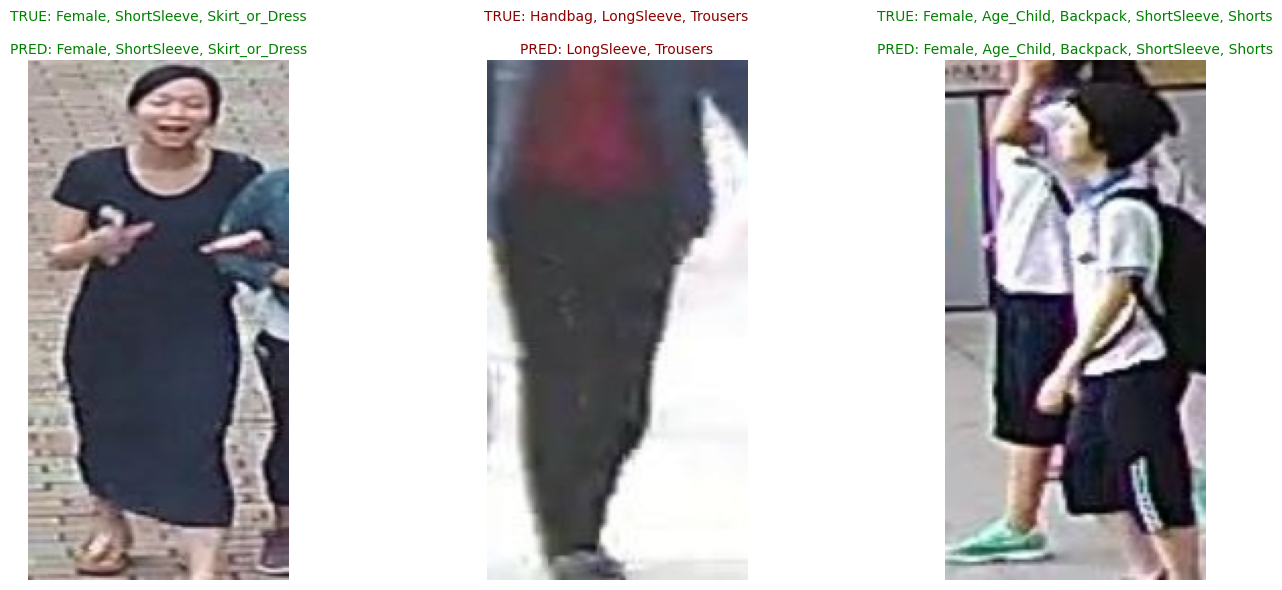

--> Saved new best checkpoint!



Ep  2/20 | Time: 1249.4s | LR: 0.00099 | p_mix: 0.1
Loss -> Train: 0.199 | Val: 0.305
Metrics -> Val Prec: 73.9% | Val Rec: 46.9% | Val F1: 54.0%


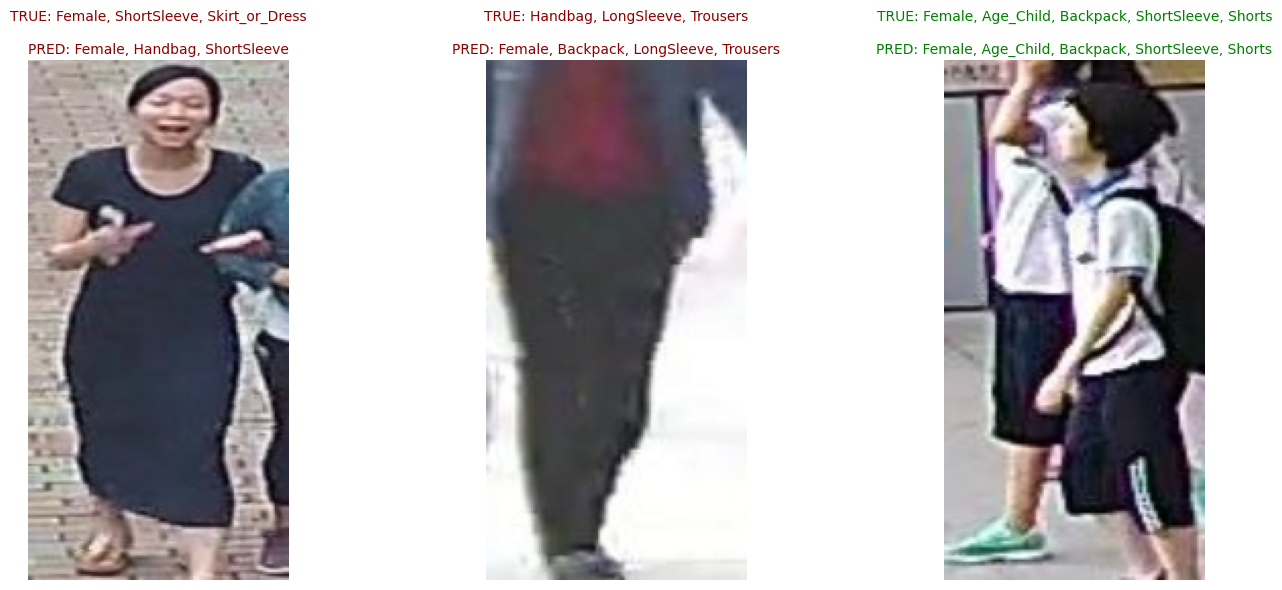

--> Saved new best checkpoint!



Ep  3/20 | Time: 1318.5s | LR: 0.00098 | p_mix: 0.1
Loss -> Train: 0.161 | Val: 0.284
Metrics -> Val Prec: 74.9% | Val Rec: 53.0% | Val F1: 59.9%


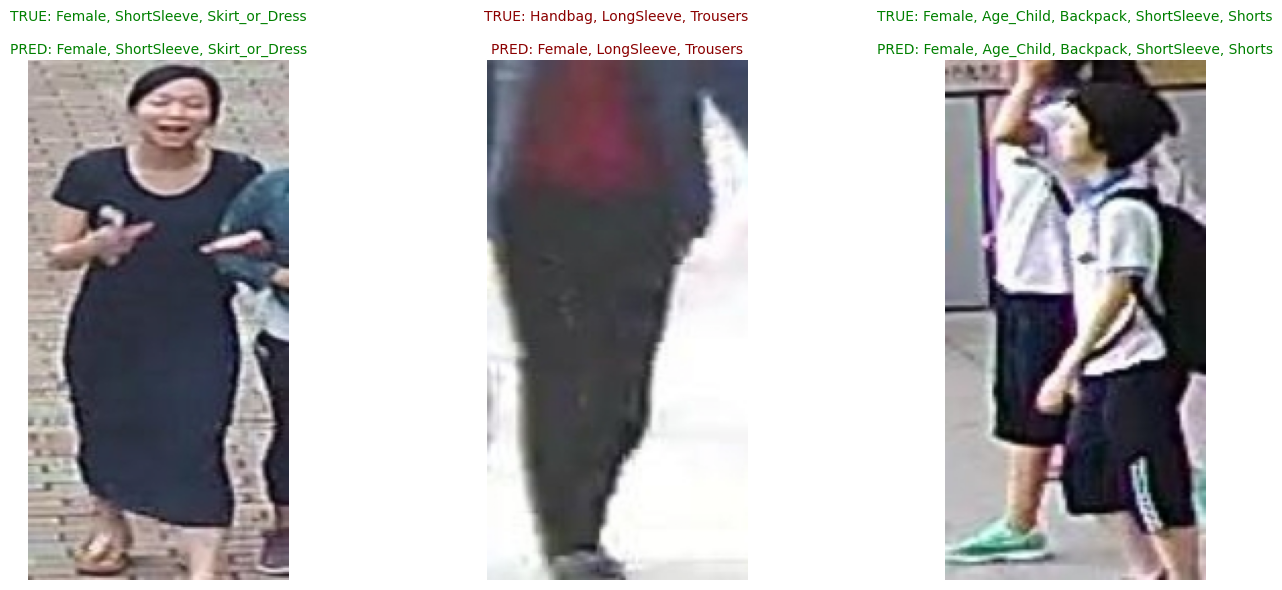

--> Saved new best checkpoint!



KeyboardInterrupt: 

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import cv2
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import time
import json

# --- 1. Transforms ---
def get_train_transforms():
    return T.Compose([
        T.RandomHorizontalFlip(p=0.5), # Natively handles the PIL Image
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_val_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- 2. Clean PIL Dataset Class ---
class UnifiedPedestrianDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.image_paths = self.df['image_path'].values
        self.attributes = self.df.iloc[:, 2:].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        try:
            # Native PIL decoding
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Fallback for corrupted images
            image = Image.new('RGB', (128, 256), (0, 0, 0))
            
        # Apply torchvision transforms (including the horizontal flip)
        if self.transform:
            image = self.transform(image)
            
        raw_labels = self.attributes[idx]
        mask = (raw_labels != -1.0).astype(np.float32)
        clean_labels = np.where(raw_labels == -1.0, 0.0, raw_labels)
        
        return image, torch.tensor(clean_labels), torch.tensor(mask)
    
    
# --- 3. Masked Loss & Metrics ---
class MaskedBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets, masks):
        raw_loss = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.pos_weight, reduction='none')
        masked_loss = raw_loss * masks
        valid_entries = masks.sum() + 1e-8
        return masked_loss.sum() / valid_entries

def calculate_masked_metrics(logits, targets, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    
    valid_preds = preds * masks
    valid_targets = targets * masks
    
    true_positives = ((valid_preds == 1.0) & (valid_targets == 1.0) & (masks == 1.0)).sum(dim=0)
    false_positives = ((valid_preds == 1.0) & (valid_targets == 0.0) & (masks == 1.0)).sum(dim=0)
    false_negatives = ((valid_preds == 0.0) & (valid_targets == 1.0) & (masks == 1.0)).sum(dim=0)
    
    epsilon = 1e-8
    precision = true_positives / (true_positives + false_positives + epsilon)
    recall = true_positives / (true_positives + false_negatives + epsilon)
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return {'precision': precision.mean().item(), 'recall': recall.mean().item(), 'f1': f1_score.mean().item()}

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_targets, all_masks = [], [], []
    
    with torch.no_grad():
        for images, labels, masks in dataloader:
            images, labels, masks = images.to(device), labels.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, labels, masks)
            total_loss += loss.item()
            
            all_logits.append(logits.cpu())
            all_targets.append(labels.cpu())
            all_masks.append(masks.cpu())
            
    full_logits = torch.cat(all_logits, dim=0)
    full_targets = torch.cat(all_targets, dim=0)
    full_masks = torch.cat(all_masks, dim=0)
    
    metrics = calculate_masked_metrics(full_logits, full_targets, full_masks)
    return total_loss / len(dataloader), metrics

# --- 4. Visualization Helper ---
schema_keys = [
    "Female", "Age_Child", "Age_Over_60", "Bald", "Short_Hair", "Long_Hair",
    "Backpack", "Hat", "Glasses", "Handbag", "MessengerBag", "PlasticBag",
    "ShortSleeve", "LongSleeve", "Trousers", "Shorts", "Skirt_or_Dress",
    "Boots", "Sneakers", "LeatherShoes"
]

def visualize_predictions(model, dataloader, schema_keys, device, num_samples=3):
    model.eval()
    images, labels, masks = next(iter(dataloader))
    images, labels, masks = images[:num_samples].to(device), labels[:num_samples].to(device), masks[:num_samples].to(device)
    
    with torch.no_grad():
        logits = model(images)
        preds = (torch.sigmoid(logits) > 0.5).float()
        
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 6))
    if num_samples == 1: axes = [axes]
        
    for i in range(num_samples):
        img = images[i].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1).permute(1, 2, 0)
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        true_text, pred_text = [], []
        for j in range(len(schema_keys)):
            if masks[i, j] == 1.0: 
                if labels[i, j] == 1.0: true_text.append(schema_keys[j])
                if preds[i, j] == 1.0:  pred_text.append(schema_keys[j])
                    
        title = f"TRUE: {', '.join(true_text)}\n\nPRED: {', '.join(pred_text)}"
        color = 'green' if set(true_text) == set(pred_text) else 'darkred'
        axes[i].set_title(title, fontsize=10, color=color, wrap=True)
        
    plt.tight_layout()
    plt.show()


train_dataset = UnifiedPedestrianDataset("./data/unified_train.csv", transform=get_train_transforms())
val_dataset = UnifiedPedestrianDataset("./data/unified_val.csv", transform=get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- INIT TRAINING ON: {device.type.upper()} ---")

# The heavy 15-block architecture
model = BestenSingle(
    num_classes=20, 
    layer_config=[(4, 64, 2), (2, 128, 2), (2, 256, 2), (4, 512, 2), (3, 1024, 2)]
).to(device)

total_epochs = 20

criterion = MaskedBCEWithLogitsLoss()
# AdamW is generally superior for multi-label Transformer/SERegNet architectures
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-5)

# Initialize the PyTorch AMP Scaler
scaler = torch.cuda.amp.GradScaler()



# ==========================================
# 2. LOGGING SETUP
# ==========================================
log_name = "par_unified_baseline"
log_dir = Path(f"logs/{log_name}")
log_dir.mkdir(parents=True, exist_ok=True)
log_file = log_dir / f"{log_name}_log.json"
log_data = []
best_f1 = 0.0
os.makedirs('./checkpoints', exist_ok=True)

# ==========================================
# 3. LIVE TRAINING LOOP
# ==========================================
print("="*85)
print(f"Starting Training on {device} | Batch: 128 | Workers: 0 (Windows Safe)")
print("="*85)

for epoch in range(1, total_epochs + 1):
    start_time = time.time()
    
    lr = scheduler.get_last_lr()[0]
    
    # Custom p_mix schedule tracking
    if epoch <= 5: p_mix = 0.1
    elif epoch <= 10: p_mix = 0.2
    elif epoch <= 12: p_mix = 0.3
    elif epoch <= 16: p_mix = 0.3
    elif epoch <= 18: p_mix = 0.3
    elif epoch <= 19: p_mix = 0.2
    else: p_mix = 0

    # --- TRAIN PHASE ---
    model.train()
    train_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc=f"Ep {epoch:02d}/{total_epochs} [Train]", leave=False)
    for images, labels, masks in train_pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        # 1. Autocast forces the GPU to use fast 16-bit math for the forward pass
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels, masks)
        
        # 2. Scaler handles the 16-bit backward pass safely without gradient underflow
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    # --- VAL PHASE ---
    model.eval()
    val_loss = 0.0
    all_logits, all_targets, all_masks = [], [], []
    
    val_pbar = tqdm(val_loader, desc=f"Ep {epoch:02d}/{total_epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for images, labels, masks in val_pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels, masks)
            
            val_loss += loss.item()
            all_logits.append(outputs.cpu())
            all_targets.append(labels.cpu())
            all_masks.append(masks.cpu())
            
            val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    scheduler.step()
    
    # Metrics Calculation
    epoch_duration = time.time() - start_time
    t_loss = train_loss / len(train_loader)
    v_loss = val_loss / len(val_loader)
    
    full_logits = torch.cat(all_logits, dim=0)
    full_targets = torch.cat(all_targets, dim=0)
    full_masks = torch.cat(all_masks, dim=0)
    val_metrics = calculate_masked_metrics(full_logits, full_targets, full_masks)
    
    v_prec = val_metrics['precision'] * 100
    v_rec = val_metrics['recall'] * 100
    v_f1 = val_metrics['f1'] * 100
    
    # JSON Logging
    log_data.append({
        "epoch": epoch, "train_loss": t_loss, "val_loss": v_loss,
        "val_prec": v_prec, "val_rec": v_rec, "val_f1": v_f1, 
        "lr": lr, "p_mix": p_mix
    })
    with open(log_file, "w") as f:
        json.dump(log_data, f, indent=4)
        
    print(f"Ep {epoch:2d}/{total_epochs} | Time: {epoch_duration:.1f}s | LR: {lr:.5f} | p_mix: {p_mix}")
    print(f"Loss -> Train: {t_loss:.3f} | Val: {v_loss:.3f}")
    print(f"Metrics -> Val Prec: {v_prec:.1f}% | Val Rec: {v_rec:.1f}% | Val F1: {v_f1:.1f}%", flush=True)
    
    # Visual Sanity Check
    visualize_predictions(model, val_loader, schema_keys, device, num_samples=3)

    # Save Checkpoint
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), f"./checkpoints/besten_single_best.pth")
        print("--> Saved new best checkpoint!\n")
    else:
        print("\n")

print("Training cycle complete.")

In [22]:
import time
import torch
import psutil
import subprocess
import statistics

def get_gpu_telemetry():
    """Queries NVIDIA drivers directly for GPU utilization and VRAM usage."""
    try:
        util = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'], 
            encoding='utf-8'
        )
        mem = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'], 
            encoding='utf-8'
        )
        return float(util.strip()), float(mem.strip())
    except:
        return 0.0, 0.0

def run_hardware_telemetry(model, dataloader, criterion, optimizer, device, num_batches=10):
    print(f"\n{'='*70}")
    print(f"--- HARDWARE TELEMETRY DIAGNOSTIC ({num_batches} BATCHES) ---")
    print(f"{'='*70}")
    
    model.train()
    iterator = iter(dataloader)
    
    # Warmup and baseline setup
    _ = next(iterator)
    _ = psutil.cpu_percent(interval=None, percpu=True) # Reset CPU counters
    
    times = {'data_load': 0.0, 'compute': 0.0}
    cpu_loads = []
    gpu_utils = []
    
    for i in range(num_batches):
        # 1. Measure Data Loading (CPU Heavy)
        t0 = time.time()
        images, labels, masks = next(iterator)
        torch.cuda.synchronize()
        times['data_load'] += (time.time() - t0)
        
        # 2. Measure Compute (GPU Heavy)
        t1 = time.time()
        images, labels, masks = images.to(device), labels.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels, masks)
        loss.backward()
        optimizer.step()
        torch.cuda.synchronize()
        times['compute'] += (time.time() - t1)
        
        # 3. Snapshot Hardware States
        cpu_loads.append(psutil.cpu_percent(interval=None, percpu=True))
        gpu_util, _ = get_gpu_telemetry()
        gpu_utils.append(gpu_util)

    # --- Data Processing ---
    avg_load = times['data_load'] / num_batches
    avg_compute = times['compute'] / num_batches
    total_batch_time = avg_load + avg_compute
    
    # Average out the CPU cores across all sampled batches
    num_cores = len(cpu_loads[0])
    avg_cpu_cores = [statistics.mean([batch[core] for batch in cpu_loads]) for core in range(num_cores)]
    avg_gpu_util = statistics.mean(gpu_utils)
    _, vram_used = get_gpu_telemetry()
    
    print(f"\n[TIMING BREAKDOWN]")
    print(f"Total Time Per Batch : {total_batch_time:.4f}s")
    print(f"-> Data Loading      : {avg_load:.4f}s ({(avg_load/total_batch_time)*100:.1f}%)")
    print(f"-> Forward/Backward  : {avg_compute:.4f}s ({(avg_compute/total_batch_time)*100:.1f}%)")
    
    print(f"\n[HARDWARE UTILIZATION]")
    print(f"GPU Utilization      : {avg_gpu_util:.1f}%")
    print(f"GPU VRAM Allocated   : {vram_used:.0f} MB")
    
    print(f"\n[CPU CORE MAP ({num_cores} Logical Cores)]")
    # Print a visual map of CPU cores being used
    for i, core_load in enumerate(avg_cpu_cores):
        bar = "█" * int(core_load / 5) # Visual bar
        print(f"Core {i:02d}: {core_load:5.1f}% | {bar}")

    print("=" * 70)

# Run the test
run_hardware_telemetry(model, train_loader, criterion, optimizer, device, num_batches=10)


--- HARDWARE TELEMETRY DIAGNOSTIC (10 BATCHES) ---

[TIMING BREAKDOWN]
Total Time Per Batch : 2.0419s
-> Data Loading      : 0.2087s (10.2%)
-> Forward/Backward  : 1.8332s (89.8%)

[HARDWARE UTILIZATION]
GPU Utilization      : 95.8%
GPU VRAM Allocated   : 6480 MB

[CPU CORE MAP (8 Logical Cores)]
Core 00:  31.2% | ██████
Core 01:  16.9% | ███
Core 02:  28.0% | █████
Core 03:  21.0% | ████
Core 04:  31.0% | ██████
Core 05:  36.0% | ███████
Core 06:  42.9% | ████████
Core 07:  52.7% | ██████████
